the additive coupling was:

x2 = z2 + t(z1)

we now consider the coumpling affine:

x2 = e^{s(z1)} z2 + t(z1)

so we are rescaling z2 and than translate it

we are mantaning the x1=z1 so it's still invertible:

z1=x1
z2= (x2-t(z1)) e^{- s(z1)} = (x2-t(x1)) e^{- s(x1)}

in this way we have the invertibility and also the triangular jacobian,

but this time is det J is not 1: 

det J = e^{s(z1)}

so that:

log det J = s(z1)

In [169]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid


In [170]:
def s(z1):
    return 0.5 * jnp.tanh(0.6*z1**3)

def t(z1):
    return z1**2

def forward(z):
    z1, z2 = z[..., 0], z[..., 1]
    x1 = z1
    x2 = z2 * jnp.exp(s(z1)) + t(z1)

    log_det = s(z1)

    x = jnp.stack([x1, x2], axis=-1)
    return x, log_det

def inverse(x):
    x1, x2 = x[..., 0], x[..., 1]

    z1 = x1
    z2 = (x2 - t(x1)) * jnp.exp(-s(x1))

    log_det = -s(x1)

    z = jnp.stack([z1, z2], axis=-1)
    return z, log_det


In [171]:
def log_pz(z):
    d = z.shape[-1]
    return -0.5 * jnp.sum(z**2, axis=-1) - (d / 2) * jnp.log(2 * jnp.pi)

def log_px(x):
    z, log_det = inverse(x)
    return log_pz(z) + log_det
# this is usefull only for the first flow, because z is not a gaussian

Sampling and Evaluating

we can aply the trasformation more than one time and see what appen to the distribution

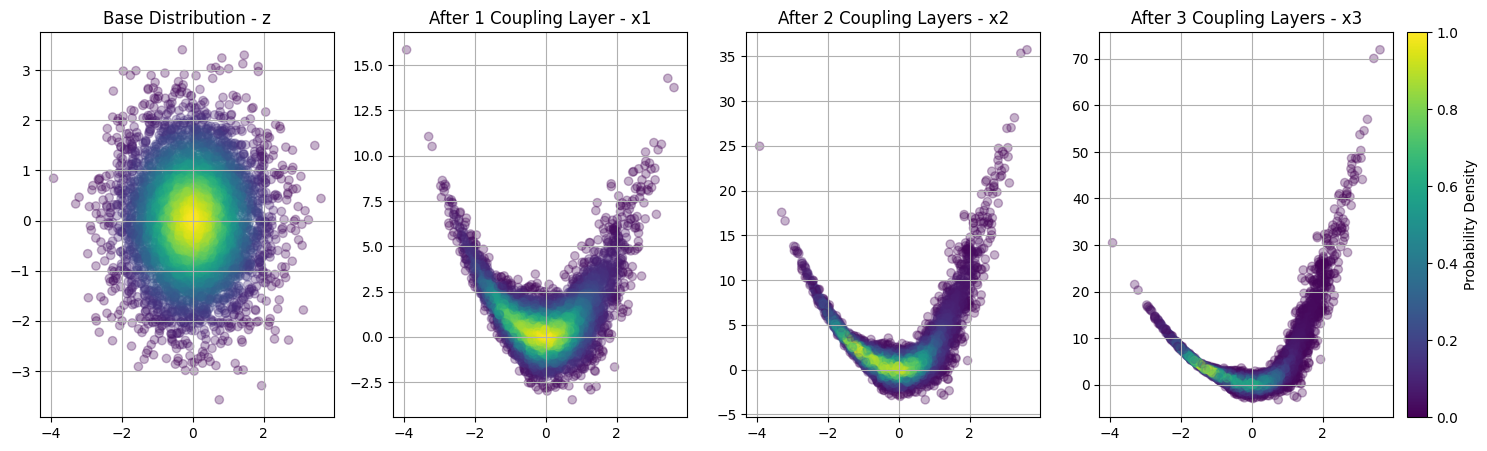

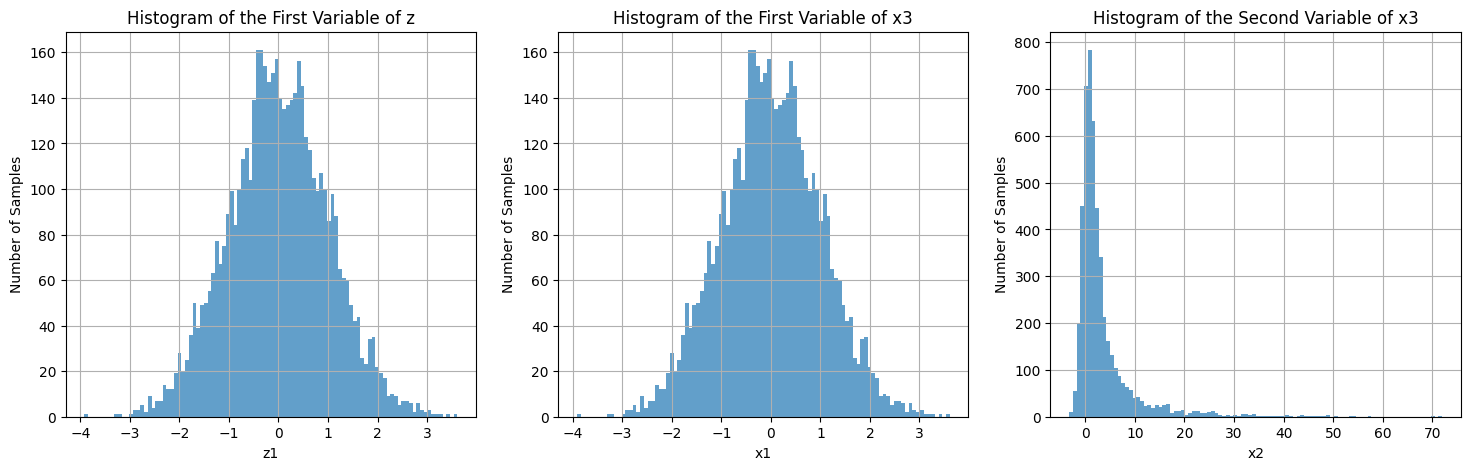

In [172]:
n_samples = 5000
key = jax.random.PRNGKey(0)
z_samples = jax.random.normal(key, (n_samples, 2))
log_prob_z = log_pz(z_samples)
prob_z = jnp.exp(log_prob_z)

x_samples1, log_det1= forward(z_samples)
log_prob_x1 = log_px(x_samples1)         # first flow
prob_x1 = jnp.exp(log_prob_x1)
x_samples2, log_det2 = forward(x_samples1)
log_prob_x2 = log_prob_x1 - log_det2          # log p(x2) = log p(x1) - log|det J2|
prob_x2 = jnp.exp(log_prob_x2)
x_samples3, log_det3 = forward(x_samples2)
log_prob_x3 = log_prob_x2 - log_det3          # log p(x3) = log p(x2) - log|det J3|
prob_x3 = jnp.exp(log_prob_x3)

plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.scatter(z_samples[:, 0], z_samples[:, 1], alpha=0.3, c=prob_z, cmap='viridis')
plt.title('Base Distribution - z')
plt.grid()
plt.subplot(1, 4, 2)
plt.scatter(x_samples1[:, 0], x_samples1[:, 1], alpha=0.3, c=prob_x1, cmap='viridis')
plt.title('After 1 Coupling Layer - x1')
plt.grid()
plt.subplot(1, 4, 3)
plt.scatter(x_samples2[:, 0], x_samples2[:, 1], alpha=0.3, c=prob_x2, cmap='viridis')
plt.title('After 2 Coupling Layers - x2')
plt.grid()
plt.subplot(1, 4, 4)
plt.scatter(x_samples3[:, 0], x_samples3[:, 1], alpha=0.3, c=prob_x3, cmap='viridis')
plt.title('After 3 Coupling Layers - x3')
plt.grid()
# color bar for all subplots
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('Probability Density')
plt.show()

#histo of the variables of x_samples3 with z_1 to see how the distribution changes after the flows, we expect x1 to be the same as z1 but x2 to be more complex
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.hist(z_samples[:, 0], bins=100, alpha=0.7, label='z')
plt.xlabel('z1')
plt.ylabel('Number of Samples')
plt.title('Histogram of the First Variable of z')
plt.grid()
plt.subplot(1, 3, 2)
plt.hist(x_samples3[:, 0], bins=100, alpha=0.7, label='x1')
plt.xlabel('x1')
plt.ylabel('Number of Samples')
plt.title('Histogram of the First Variable of x3')
plt.grid()
plt.subplot(1, 3, 3)
plt.hist(x_samples3[:, 1], bins=100, alpha=0.7, label='x2')
plt.xlabel('x2')
plt.ylabel('Number of Samples')
plt.title('Histogram of the Second Variable of x3')
plt.grid()
plt.show()


Notice that the change has append only in the x2 values, because the trasfromation is changing only x2 and not x1.